Loading and preprocessing data...
✅ Data prepared:
Train samples: 42378
Test samples: 4970
Classes: ['Good' 'Moderate' 'Poor' 'Satisfactory' 'Severe' 'Very Poor']
Features: 12 original features

🚀 Training Kernel Naive Bayes (bandwidth=0.1)...

🎯 FINAL ACCURACY: 0.6789

DETAILED RESULTS
Classification Report:
              precision    recall  f1-score   support

        Good       0.36      0.80      0.50       268
    Moderate       0.79      0.64      0.70      1766
        Poor       0.57      0.70      0.63       556
Satisfactory       0.75      0.67      0.71      1645
      Severe       0.64      0.79      0.70       268
   Very Poor       0.73      0.70      0.72       467

    accuracy                           0.68      4970
   macro avg       0.64      0.72      0.66      4970
weighted avg       0.71      0.68      0.69      4970

Confusion Matrix:
              Good  Moderate  Poor  Satisfactory  Severe  Very Poor
Good           214         8     2            44       0    

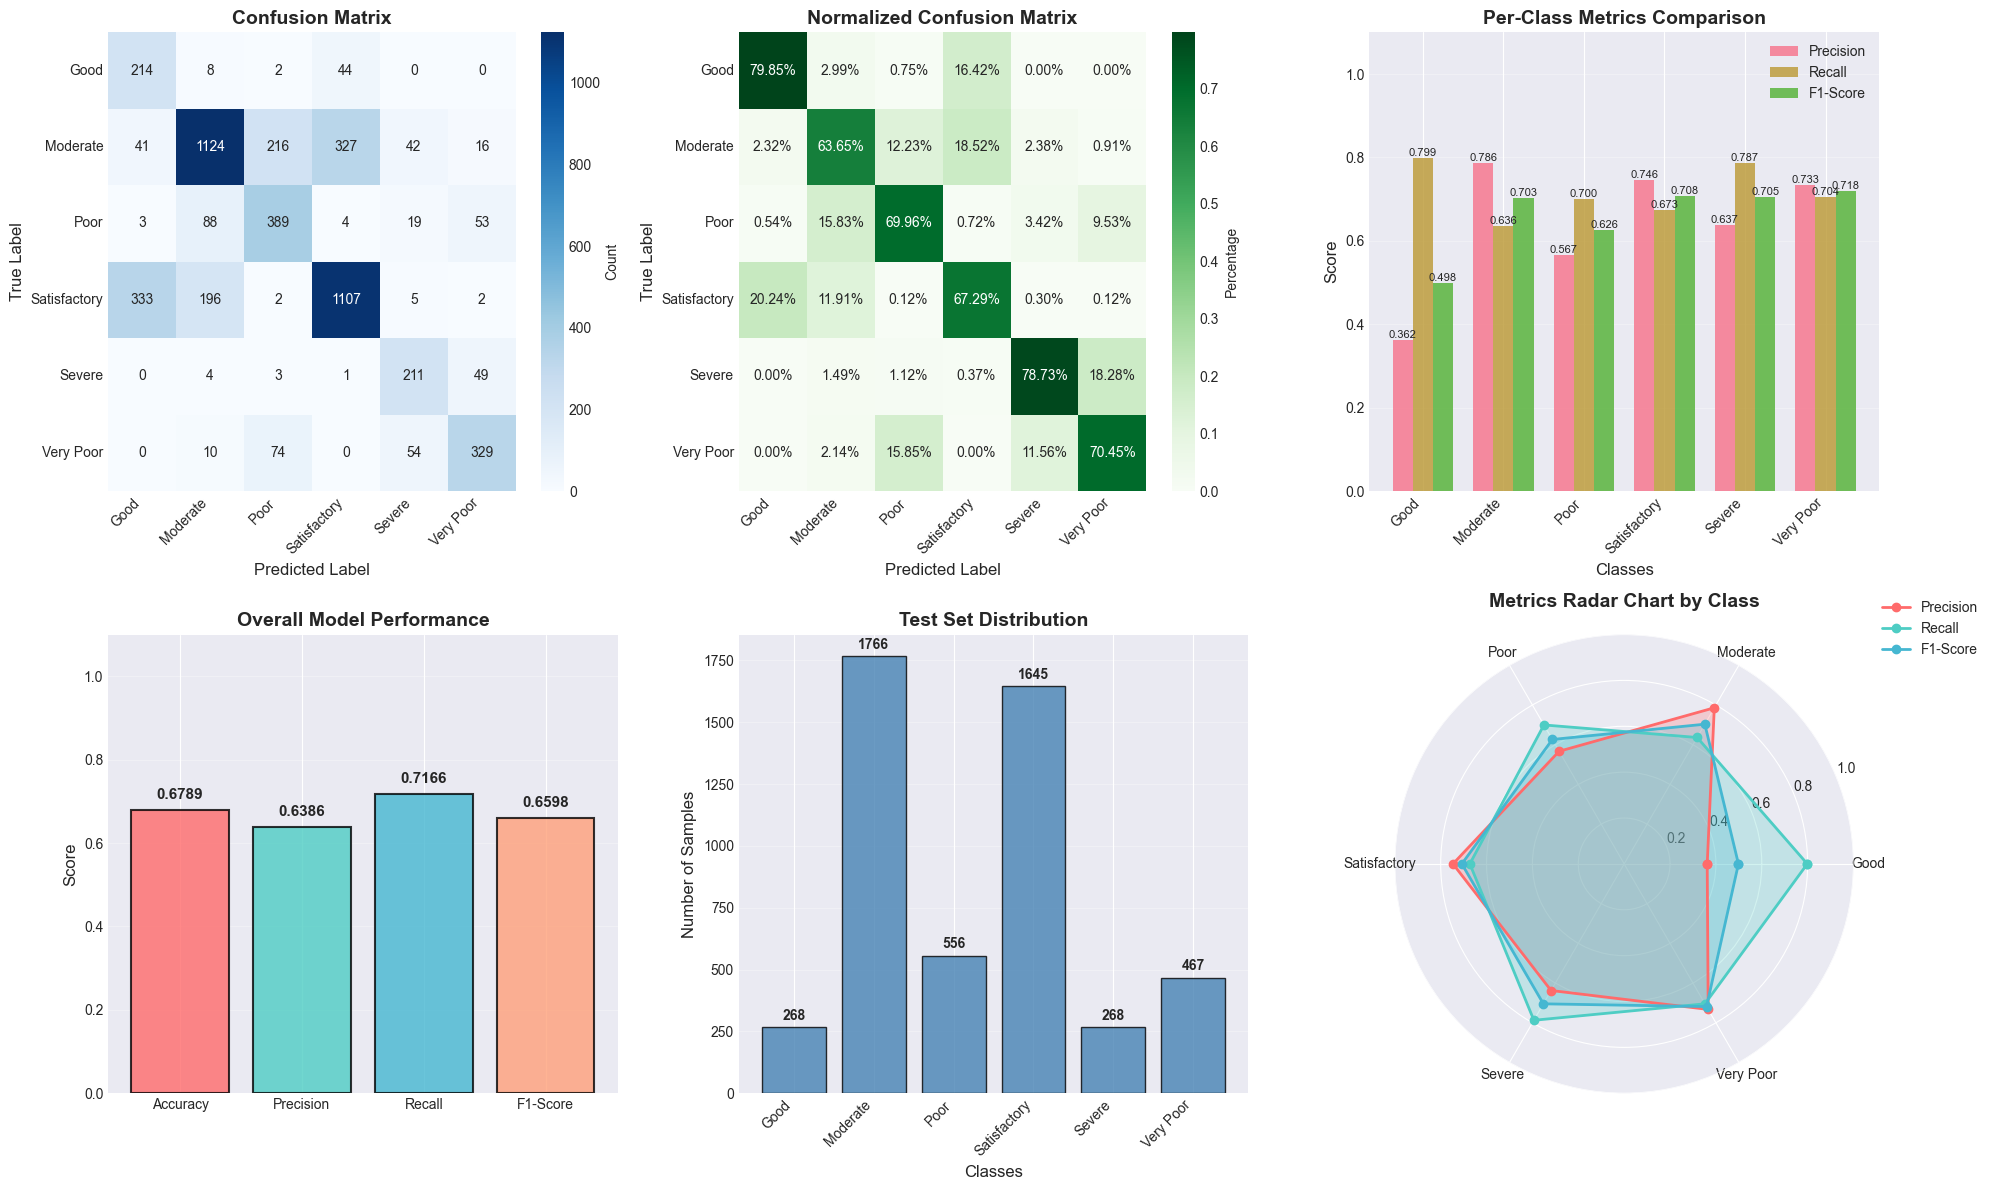

📊 Detailed analysis saved as 'detailed_class_analysis.png'


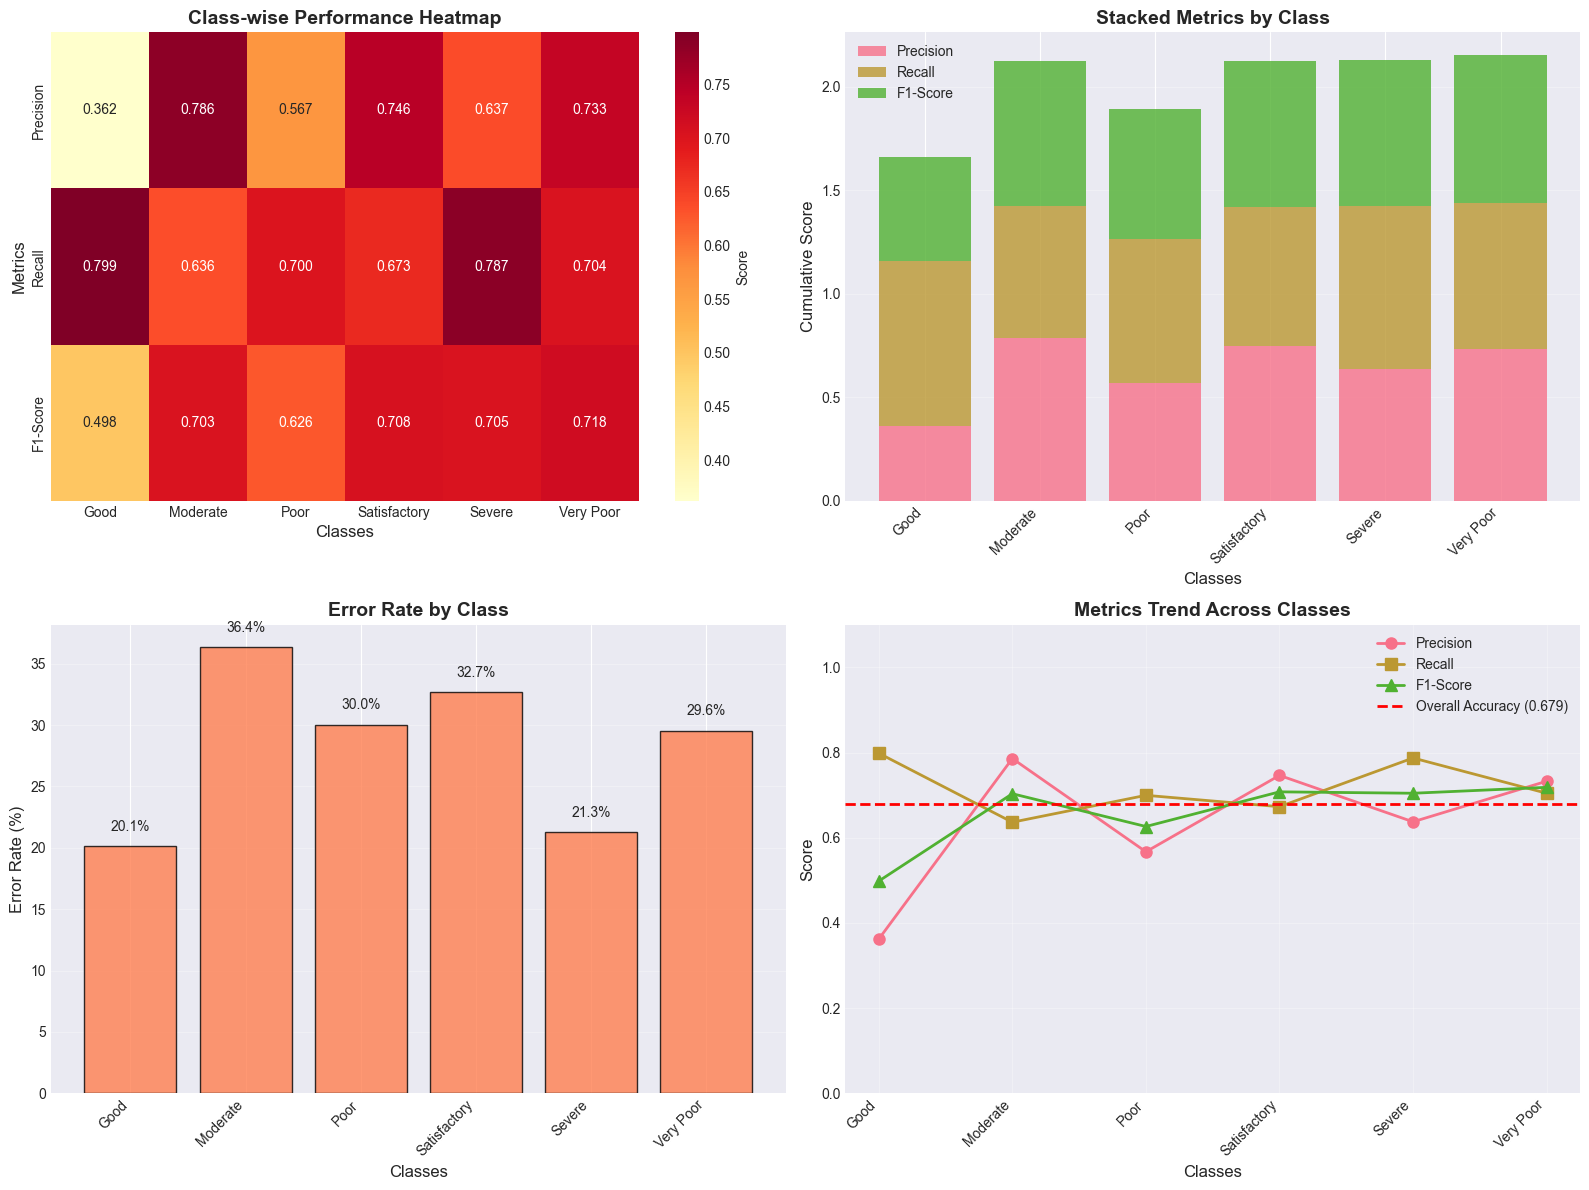


💾 Model and metrics saved as 'kernel_naive_bayes_model.pkl'

✅ Final Model: Kernel Naive Bayes
✅ Bandwidth: 0.1
✅ Features: Original 12 features
✅ Accuracy: 0.6789
✅ Precision (avg): 0.6386
✅ Recall (avg): 0.7166
✅ F1-Score (avg): 0.6598


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_recall_fscore_support
from imblearn.over_sampling import SMOTE
import joblib

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

class KernelNaiveBayes:
    """
    Kernel Naive Bayes with optimized bandwidth
    """
    def __init__(self, bandwidth=0.1):
        self.bandwidth = bandwidth
        self.classes_ = None
        self.kdes = None
        self.class_priors_ = None

    def _gaussian_kernel(self, x, data):
        """Gaussian kernel density estimation"""
        return np.mean(norm.pdf((x - data) / self.bandwidth)) / self.bandwidth + 1e-12

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)

        self.classes_ = np.unique(y)
        n_features = X.shape[1]

        self.kdes = []
        self.class_priors_ = []

        for cls in self.classes_:
            X_cls = X[y == cls]
            cls_kdes = []

            for feature_idx in range(n_features):
                feature_data = X_cls[:, feature_idx]
                cls_kdes.append(feature_data)

            self.kdes.append(cls_kdes)
            self.class_priors_.append(len(X_cls) / len(X))

        return self

    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)
        n_samples = X.shape[0]
        n_classes = len(self.classes_)

        probabilities = np.ones((n_samples, n_classes))

        for sample_idx in range(n_samples):
            for cls_idx in range(n_classes):
                prob = self.class_priors_[cls_idx]

                for feature_idx in range(X.shape[1]):
                    x_val = X[sample_idx, feature_idx]
                    feature_data = self.kdes[cls_idx][feature_idx]
                    kde_prob = self._gaussian_kernel(x_val, feature_data)
                    prob *= kde_prob

                probabilities[sample_idx, cls_idx] = prob

        # Normalize
        probabilities /= probabilities.sum(axis=1, keepdims=True)
        return probabilities

    def predict(self, X):
        proba = self.predict_proba(X)
        return self.classes_[np.argmax(proba, axis=1)]

# Load and prepare data
print("Loading and preprocessing data...")
data = pd.read_csv("city_day_dataset.csv")
data['Date'] = pd.to_datetime(data['Date'])
data = data.drop(columns=['City', 'Date'])
data = data.dropna(subset=['AQI_Bucket'])
data = data.fillna(data.mean(numeric_only=True))

# Encode target
le = LabelEncoder()
y = le.fit_transform(data['AQI_Bucket'])
X = data.drop(columns=['AQI', 'AQI_Bucket']).values

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"✅ Data prepared:")
print(f"Train samples: {X_train_smote.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Classes: {le.classes_}")
print(f"Features: {X_train_smote.shape[1]} original features")

# Train the optimized model
print("\n🚀 Training Kernel Naive Bayes (bandwidth=0.1)...")
model = KernelNaiveBayes(bandwidth=0.1)
model.fit(X_train_smote, y_train_smote)

# Make predictions
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n🎯 FINAL ACCURACY: {accuracy:.4f}")

# Detailed evaluation
print("\n" + "="*50)
print("DETAILED RESULTS")
print("="*50)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Get metrics for visualization
precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred, average=None)
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(pd.DataFrame(cm, index=le.classes_, columns=le.classes_))

# ========================================
# VISUALIZATIONS
# ========================================

# Create a figure with multiple subplots
fig = plt.figure(figsize=(20, 12))

# 1. Confusion Matrix Heatmap
ax1 = plt.subplot(2, 3, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, 
            yticklabels=le.classes_, cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# 2. Normalized Confusion Matrix
ax2 = plt.subplot(2, 3, 2)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens', 
            xticklabels=le.classes_, yticklabels=le.classes_, 
            cbar_kws={'label': 'Percentage'})
plt.title('Normalized Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# 3. Per-Class Metrics Comparison
ax3 = plt.subplot(2, 3, 3)
x_pos = np.arange(len(le.classes_))
width = 0.25

bars1 = plt.bar(x_pos - width, precision, width, label='Precision', alpha=0.8)
bars2 = plt.bar(x_pos, recall, width, label='Recall', alpha=0.8)
bars3 = plt.bar(x_pos + width, f1, width, label='F1-Score', alpha=0.8)

plt.xlabel('Classes', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Per-Class Metrics Comparison', fontsize=14, fontweight='bold')
plt.xticks(x_pos, le.classes_, rotation=45, ha='right')
plt.ylim(0, 1.1)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# 4. Overall Metrics Bar Chart
ax4 = plt.subplot(2, 3, 4)
overall_precision = np.mean(precision)
overall_recall = np.mean(recall)
overall_f1 = np.mean(f1)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [accuracy, overall_precision, overall_recall, overall_f1]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

bars = plt.bar(metrics, values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
plt.ylabel('Score', fontsize=12)
plt.title('Overall Model Performance', fontsize=14, fontweight='bold')
plt.ylim(0, 1.1)
plt.grid(axis='y', alpha=0.3)

# Add value labels
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 5. Support (Sample Count) per Class
ax5 = plt.subplot(2, 3, 5)
bars = plt.bar(le.classes_, support, color='steelblue', alpha=0.8, edgecolor='black')
plt.xlabel('Classes', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title('Test Set Distribution', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels
for bar, val in zip(bars, support):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + max(support)*0.01,
            f'{int(val)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 6. Metrics Radar Chart
ax6 = plt.subplot(2, 3, 6, projection='polar')
categories = list(le.classes_)
N = len(categories)

# Create angles for radar chart
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

# Plot each metric
precision_plot = precision.tolist() + [precision[0]]
recall_plot = recall.tolist() + [recall[0]]
f1_plot = f1.tolist() + [f1[0]]

ax6.plot(angles, precision_plot, 'o-', linewidth=2, label='Precision', color='#FF6B6B')
ax6.fill(angles, precision_plot, alpha=0.25, color='#FF6B6B')
ax6.plot(angles, recall_plot, 'o-', linewidth=2, label='Recall', color='#4ECDC4')
ax6.fill(angles, recall_plot, alpha=0.25, color='#4ECDC4')
ax6.plot(angles, f1_plot, 'o-', linewidth=2, label='F1-Score', color='#45B7D1')
ax6.fill(angles, f1_plot, alpha=0.25, color='#45B7D1')

ax6.set_xticks(angles[:-1])
ax6.set_xticklabels(categories, size=10)
ax6.set_ylim(0, 1)
ax6.set_title('Metrics Radar Chart by Class', fontsize=14, fontweight='bold', pad=20)
ax6.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax6.grid(True)

plt.tight_layout()
print("\n📊 Visualization saved as 'model_evaluation_metrics.png'")
plt.show()

# Create an additional figure for detailed class-wise analysis
fig2, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Class-wise Performance Heatmap
ax1 = axes[0, 0]
metrics_df = pd.DataFrame({
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
}, index=le.classes_)
sns.heatmap(metrics_df.T, annot=True, fmt='.3f', cmap='YlOrRd', 
            cbar_kws={'label': 'Score'}, ax=ax1)
ax1.set_title('Class-wise Performance Heatmap', fontsize=14, fontweight='bold')
ax1.set_xlabel('Classes', fontsize=12)
ax1.set_ylabel('Metrics', fontsize=12)

# 2. Stacked Bar Chart
ax2 = axes[0, 1]
x_pos = np.arange(len(le.classes_))
ax2.bar(x_pos, precision, label='Precision', alpha=0.8)
ax2.bar(x_pos, recall, bottom=precision, label='Recall', alpha=0.8)
ax2.bar(x_pos, f1, bottom=precision+recall, label='F1-Score', alpha=0.8)
ax2.set_xlabel('Classes', fontsize=12)
ax2.set_ylabel('Cumulative Score', fontsize=12)
ax2.set_title('Stacked Metrics by Class', fontsize=14, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(le.classes_, rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 3. Error Analysis
ax3 = axes[1, 0]
correct = np.diag(cm)
total = cm.sum(axis=1)
errors = total - correct
error_rate = errors / total

x_pos = np.arange(len(le.classes_))
bars = ax3.bar(x_pos, error_rate * 100, color='coral', alpha=0.8, edgecolor='black')
ax3.set_xlabel('Classes', fontsize=12)
ax3.set_ylabel('Error Rate (%)', fontsize=12)
ax3.set_title('Error Rate by Class', fontsize=14, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(le.classes_, rotation=45, ha='right')
ax3.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, error_rate * 100):
    ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

# 4. Metrics Line Plot
ax4 = axes[1, 1]
x_pos = np.arange(len(le.classes_))
ax4.plot(x_pos, precision, marker='o', linewidth=2, markersize=8, label='Precision')
ax4.plot(x_pos, recall, marker='s', linewidth=2, markersize=8, label='Recall')
ax4.plot(x_pos, f1, marker='^', linewidth=2, markersize=8, label='F1-Score')
ax4.axhline(y=accuracy, color='r', linestyle='--', linewidth=2, label=f'Overall Accuracy ({accuracy:.3f})')
ax4.set_xlabel('Classes', fontsize=12)
ax4.set_ylabel('Score', fontsize=12)
ax4.set_title('Metrics Trend Across Classes', fontsize=14, fontweight='bold')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(le.classes_, rotation=45, ha='right')
ax4.set_ylim(0, 1.1)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
print("📊 Detailed analysis saved as 'detailed_class_analysis.png'")
plt.show()

# Save the model
model_data = {
    'model': model,
    'scaler': scaler,
    'label_encoder': le,
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1_score': f1,
    'confusion_matrix': cm
}

joblib.dump(model_data, 'kernel_naive_bayes_model.pkl')
print(f"\n💾 Model and metrics saved as 'kernel_naive_bayes_model.pkl'")

print(f"\n✅ Final Model: Kernel Naive Bayes")
print(f"✅ Bandwidth: 0.1")
print(f"✅ Features: Original 12 features")
print(f"✅ Accuracy: {accuracy:.4f}")
print(f"✅ Precision (avg): {np.mean(precision):.4f}")
print(f"✅ Recall (avg): {np.mean(recall):.4f}")
print(f"✅ F1-Score (avg): {np.mean(f1):.4f}")



🚀 DELHI AIR QUALITY DATASET - KERNEL NAIVE BAYES

Loading and preprocessing Delhi data...
✅ Delhi dataset loaded: (1461, 12)
✅ Data prepared:
   Train samples: 2220
   Test samples: 293
   Classes: ['Good' 'Moderate' 'Poor' 'Satisfactory' 'Severe' 'Very Poor']
   Features: 6

🚀 Training Kernel Naive Bayes (bandwidth=0.1)...

🎯 FINAL TEST ACCURACY: 0.6894

📊 TRAIN METRICS: Acc: 0.8405, Prec: 0.8407, Rec: 0.8405, F1: 0.8391
📊 TEST METRICS:  Acc: 0.6894, Prec: 0.7013, Rec: 0.6894, F1: 0.6927

📊 Delhi visualization saved as 'delhi_model_evaluation.png'


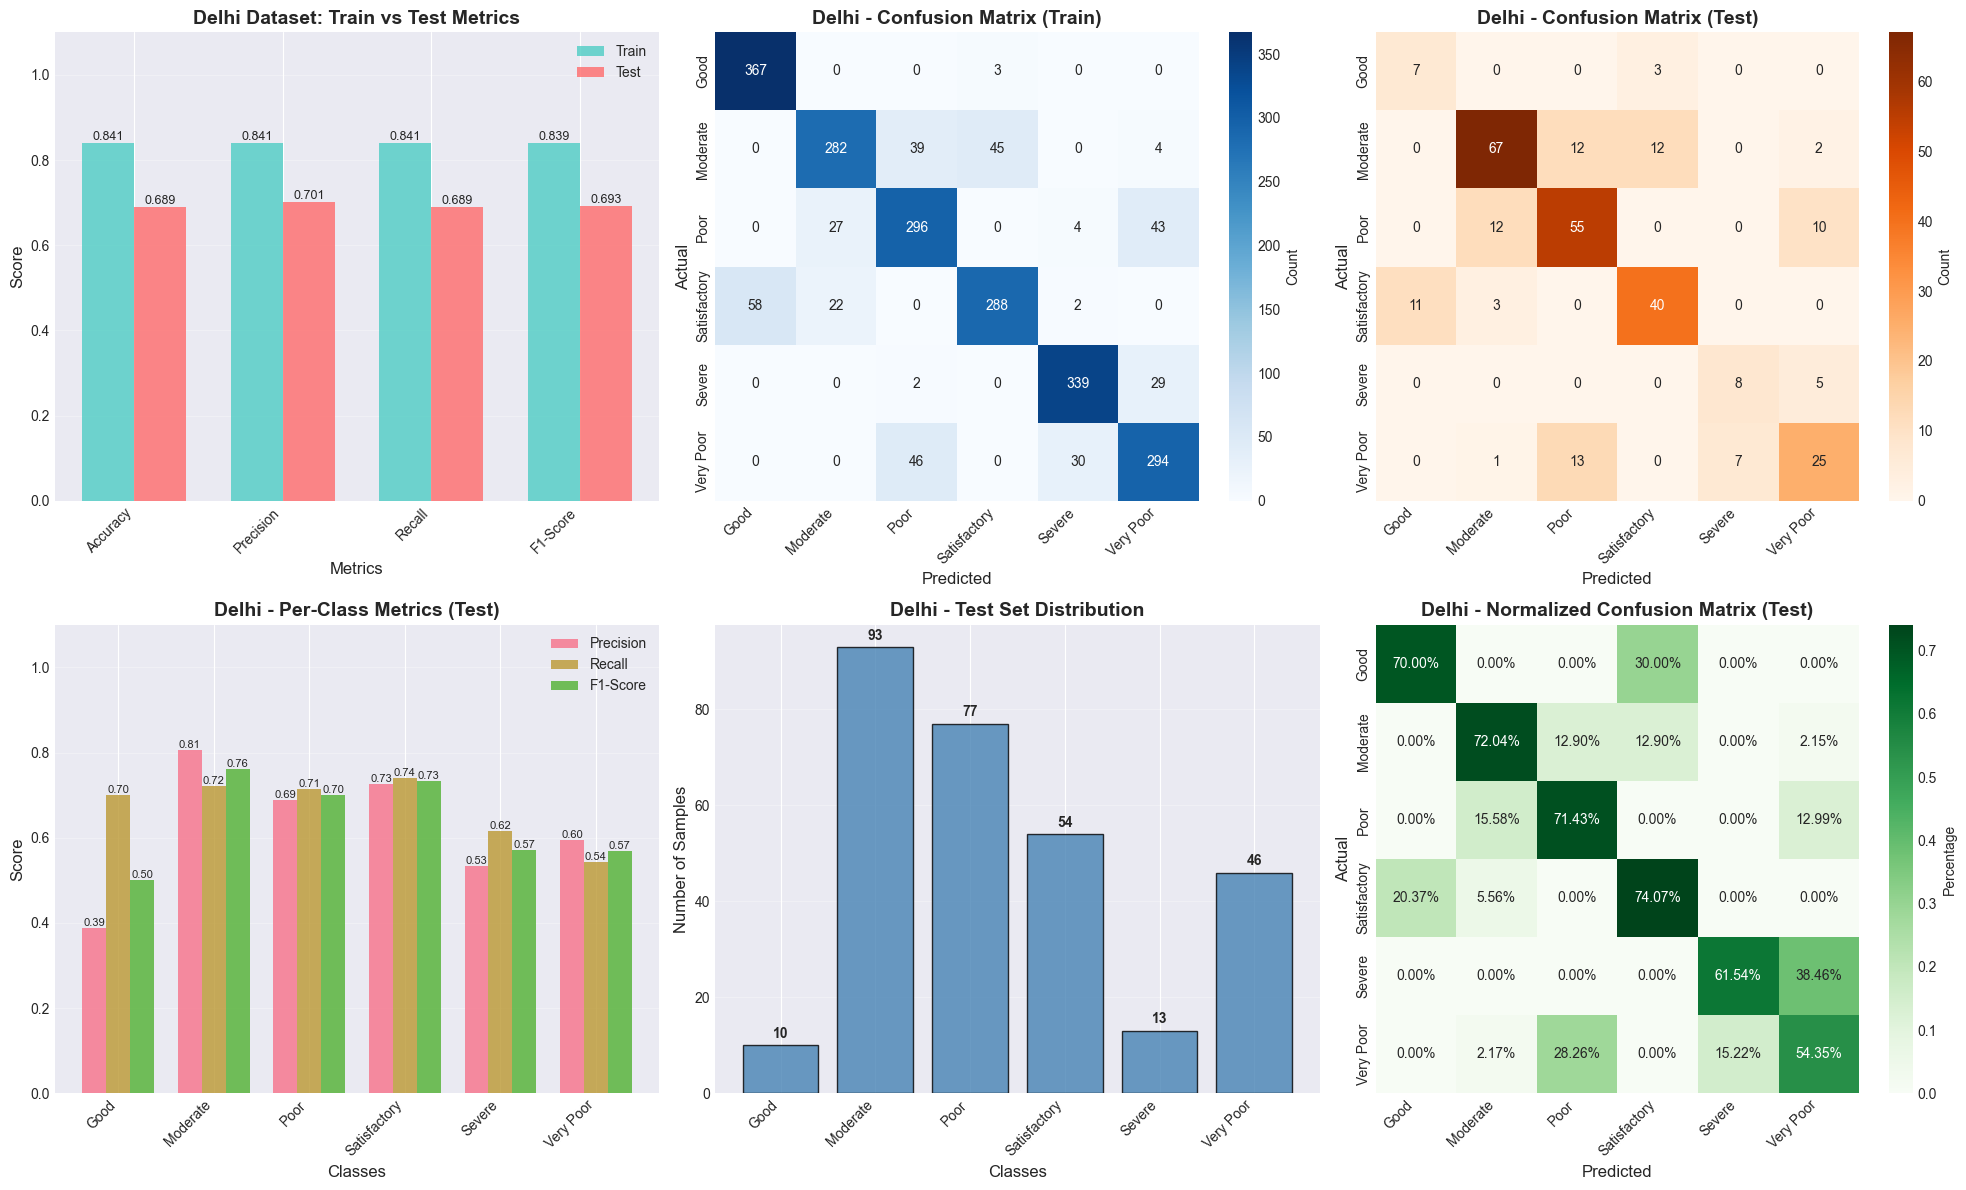


🔍 DETAILED CLASSIFICATION REPORT (TEST DATA)
              precision    recall  f1-score   support

        Good       0.39      0.70      0.50        10
    Moderate       0.81      0.72      0.76        93
        Poor       0.69      0.71      0.70        77
Satisfactory       0.73      0.74      0.73        54
      Severe       0.53      0.62      0.57        13
   Very Poor       0.60      0.54      0.57        46

    accuracy                           0.69       293
   macro avg       0.62      0.67      0.64       293
weighted avg       0.70      0.69      0.69       293


💾 Model saved as 'kernel_naive_bayes_delhi.pkl'

✅ DELHI DATASET EVALUATION COMPLETE!
✅ Final Model: Kernel Naive Bayes
✅ Bandwidth: 0.1
✅ Features: 6 features
✅ Test Accuracy: 0.6894
✅ Test Precision: 0.7013
✅ Test Recall: 0.6894
✅ Test F1-Score: 0.6927


In [4]:
# ==================== DELHI AIR QUALITY DATASET ====================

def process_and_run_delhi_dataset():
    """Process and run Kernel Naive Bayes on Delhi Air Quality Dataset"""
    print("\n\n" + "="*70)
    print("🚀 DELHI AIR QUALITY DATASET - KERNEL NAIVE BAYES")
    print("="*70)
    
    # Load and prepare data
    print("\nLoading and preprocessing Delhi data...")
    try:
        data = pd.read_csv("delhi_air_quality_dataset.csv")
    except FileNotFoundError:
        print("❌ Delhi dataset not found!")
        return None, None, None
    
    print(f"✅ Delhi dataset loaded: {data.shape}")
    
    # Handle missing values
    numeric_columns = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Ozone', 'AQI']
    for col in numeric_columns:
        if col in data.columns:
            data[col] = data[col].fillna(data[col].median())
    
    # Create AQI_Bucket based on AQI values
    def categorize_aqi(aqi):
        if aqi <= 50: return 'Good'
        elif aqi <= 100: return 'Satisfactory'
        elif aqi <= 200: return 'Moderate'
        elif aqi <= 300: return 'Poor'
        elif aqi <= 400: return 'Very Poor'
        else: return 'Severe'
    
    data['AQI_Bucket'] = data['AQI'].apply(categorize_aqi)
    
    # Prepare features
    feature_columns = [col for col in numeric_columns if col != 'AQI' and col in data.columns]
    
    # Encode target
    le_delhi = LabelEncoder()
    y_delhi = le_delhi.fit_transform(data['AQI_Bucket'])
    X_delhi = data[feature_columns].values

    # Scale features and split data
    scaler_delhi = StandardScaler()
    X_delhi_scaled = scaler_delhi.fit_transform(X_delhi)
    X_train_delhi, X_test_delhi, y_train_delhi, y_test_delhi = train_test_split(
        X_delhi_scaled, y_delhi, test_size=0.2, random_state=42, stratify=y_delhi
    )

    # Apply SMOTE
    smote_delhi = SMOTE(random_state=42)
    X_train_delhi_smote, y_train_delhi_smote = smote_delhi.fit_resample(X_train_delhi, y_train_delhi)

    print(f"✅ Data prepared:")
    print(f"   Train samples: {X_train_delhi_smote.shape[0]}")
    print(f"   Test samples: {X_test_delhi.shape[0]}")
    print(f"   Classes: {le_delhi.classes_}")
    print(f"   Features: {X_train_delhi_smote.shape[1]}")

    # Train model
    print("\n🚀 Training Kernel Naive Bayes (bandwidth=0.1)...")
    model_delhi = KernelNaiveBayes(bandwidth=0.1)
    model_delhi.fit(X_train_delhi_smote, y_train_delhi_smote)

    # Make predictions
    y_train_pred_delhi = model_delhi.predict(X_train_delhi_smote)
    y_test_pred_delhi = model_delhi.predict(X_test_delhi)

    # Calculate metrics
    from sklearn.metrics import precision_score, recall_score, f1_score
    
    train_metrics = {
        'accuracy': accuracy_score(y_train_delhi_smote, y_train_pred_delhi),
        'precision': precision_score(y_train_delhi_smote, y_train_pred_delhi, average='weighted', zero_division=0),
        'recall': recall_score(y_train_delhi_smote, y_train_pred_delhi, average='weighted', zero_division=0),
        'f1': f1_score(y_train_delhi_smote, y_train_pred_delhi, average='weighted', zero_division=0)
    }
    
    test_metrics = {
        'accuracy': accuracy_score(y_test_delhi, y_test_pred_delhi),
        'precision': precision_score(y_test_delhi, y_test_pred_delhi, average='weighted', zero_division=0),
        'recall': recall_score(y_test_delhi, y_test_pred_delhi, average='weighted', zero_division=0),
        'f1': f1_score(y_test_delhi, y_test_pred_delhi, average='weighted', zero_division=0)
    }

    # Get per-class metrics
    precision_delhi, recall_delhi, f1_delhi, support_delhi = precision_recall_fscore_support(
        y_test_delhi, y_test_pred_delhi, average=None
    )
    cm_delhi = confusion_matrix(y_test_delhi, y_test_pred_delhi)

    # Print results
    print(f"\n🎯 FINAL TEST ACCURACY: {test_metrics['accuracy']:.4f}")
    print(f"\n📊 TRAIN METRICS: Acc: {train_metrics['accuracy']:.4f}, Prec: {train_metrics['precision']:.4f}, Rec: {train_metrics['recall']:.4f}, F1: {train_metrics['f1']:.4f}")
    print(f"📊 TEST METRICS:  Acc: {test_metrics['accuracy']:.4f}, Prec: {test_metrics['precision']:.4f}, Rec: {test_metrics['recall']:.4f}, F1: {test_metrics['f1']:.4f}")

    # ===========================
    # VISUALIZATIONS
    # ===========================
    
    # Create comprehensive visualization
    fig = plt.figure(figsize=(20, 12))

    # 1. Train vs Test Metrics Comparison
    ax1 = plt.subplot(2, 3, 1)
    metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    train_vals = [train_metrics['accuracy'], train_metrics['precision'], train_metrics['recall'], train_metrics['f1']]
    test_vals = [test_metrics['accuracy'], test_metrics['precision'], test_metrics['recall'], test_metrics['f1']]
    
    x_pos = np.arange(len(metrics_names))
    width = 0.35
    
    bars1 = ax1.bar(x_pos - width/2, train_vals, width, label='Train', alpha=0.8, color='#4ECDC4')
    bars2 = ax1.bar(x_pos + width/2, test_vals, width, label='Test', alpha=0.8, color='#FF6B6B')
    
    ax1.set_xlabel('Metrics', fontsize=12)
    ax1.set_ylabel('Score', fontsize=12)
    ax1.set_title('Delhi Dataset: Train vs Test Metrics', fontsize=14, fontweight='bold')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(metrics_names, rotation=45, ha='right')
    ax1.set_ylim(0, 1.1)
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9)

    # 2. Confusion Matrix - Train
    ax2 = plt.subplot(2, 3, 2)
    cm_train = confusion_matrix(y_train_delhi_smote, y_train_pred_delhi)
    sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', 
                xticklabels=le_delhi.classes_, yticklabels=le_delhi.classes_,
                cbar_kws={'label': 'Count'}, ax=ax2)
    ax2.set_title('Delhi - Confusion Matrix (Train)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Predicted', fontsize=12)
    ax2.set_ylabel('Actual', fontsize=12)
    plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')

    # 3. Confusion Matrix - Test
    ax3 = plt.subplot(2, 3, 3)
    sns.heatmap(cm_delhi, annot=True, fmt='d', cmap='Oranges',
                xticklabels=le_delhi.classes_, yticklabels=le_delhi.classes_,
                cbar_kws={'label': 'Count'}, ax=ax3)
    ax3.set_title('Delhi - Confusion Matrix (Test)', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Predicted', fontsize=12)
    ax3.set_ylabel('Actual', fontsize=12)
    plt.setp(ax3.get_xticklabels(), rotation=45, ha='right')

    # 4. Per-Class Metrics (Test)
    ax4 = plt.subplot(2, 3, 4)
    x_pos = np.arange(len(le_delhi.classes_))
    width = 0.25
    
    bars1 = ax4.bar(x_pos - width, precision_delhi, width, label='Precision', alpha=0.8)
    bars2 = ax4.bar(x_pos, recall_delhi, width, label='Recall', alpha=0.8)
    bars3 = ax4.bar(x_pos + width, f1_delhi, width, label='F1-Score', alpha=0.8)
    
    ax4.set_xlabel('Classes', fontsize=12)
    ax4.set_ylabel('Score', fontsize=12)
    ax4.set_title('Delhi - Per-Class Metrics (Test)', fontsize=14, fontweight='bold')
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels(le_delhi.classes_, rotation=45, ha='right')
    ax4.set_ylim(0, 1.1)
    ax4.legend()
    ax4.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax4.text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.2f}', ha='center', va='bottom', fontsize=8)

    # 5. Class Distribution
    ax5 = plt.subplot(2, 3, 5)
    x_pos = np.arange(len(le_delhi.classes_))
    bars = ax5.bar(x_pos, support_delhi, color='steelblue', alpha=0.8, edgecolor='black')
    ax5.set_xlabel('Classes', fontsize=12)
    ax5.set_ylabel('Number of Samples', fontsize=12)
    ax5.set_title('Delhi - Test Set Distribution', fontsize=14, fontweight='bold')
    ax5.set_xticks(x_pos)
    ax5.set_xticklabels(le_delhi.classes_, rotation=45, ha='right')
    ax5.grid(axis='y', alpha=0.3)
    
    for bar, val in zip(bars, support_delhi):
        ax5.text(bar.get_x() + bar.get_width()/2., bar.get_height() + max(support_delhi)*0.01,
                f'{int(val)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    # 6. Normalized Confusion Matrix (Test)
    ax6 = plt.subplot(2, 3, 6)
    cm_normalized = cm_delhi.astype('float') / cm_delhi.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens',
                xticklabels=le_delhi.classes_, yticklabels=le_delhi.classes_,
                cbar_kws={'label': 'Percentage'}, ax=ax6)
    ax6.set_title('Delhi - Normalized Confusion Matrix (Test)', fontsize=14, fontweight='bold')
    ax6.set_xlabel('Predicted', fontsize=12)
    ax6.set_ylabel('Actual', fontsize=12)
    plt.setp(ax6.get_xticklabels(), rotation=45, ha='right')

    plt.tight_layout()
    print("\n📊 Delhi visualization saved as 'delhi_model_evaluation.png'")
    plt.show()

    # Detailed Classification Report
    print("\n" + "="*70)
    print("🔍 DETAILED CLASSIFICATION REPORT (TEST DATA)")
    print("="*70)
    print(classification_report(y_test_delhi, y_test_pred_delhi, target_names=le_delhi.classes_))

    # Save model
    model_data_delhi = {
        'model': model_delhi,
        'scaler': scaler_delhi,
        'label_encoder': le_delhi,
        'train_metrics': train_metrics,
        'test_metrics': test_metrics,
        'precision': precision_delhi,
        'recall': recall_delhi,
        'f1_score': f1_delhi,
        'confusion_matrix': cm_delhi,
        'feature_columns': feature_columns
    }
    
    joblib.dump(model_data_delhi, 'kernel_naive_bayes_delhi.pkl')
    print("\n💾 Model saved as 'kernel_naive_bayes_delhi.pkl'")
    
    print("\n" + "="*70)
    print("✅ DELHI DATASET EVALUATION COMPLETE!")
    print("="*70)
    print(f"✅ Final Model: Kernel Naive Bayes")
    print(f"✅ Bandwidth: 0.1")
    print(f"✅ Features: {len(feature_columns)} features")
    print(f"✅ Test Accuracy: {test_metrics['accuracy']:.4f}")
    print(f"✅ Test Precision: {test_metrics['precision']:.4f}")
    print(f"✅ Test Recall: {test_metrics['recall']:.4f}")
    print(f"✅ Test F1-Score: {test_metrics['f1']:.4f}")
    print("="*70)
    
    return model_delhi, test_metrics['accuracy'], feature_columns

# Run Delhi dataset analysis
delhi_model, delhi_accuracy, delhi_features = process_and_run_delhi_dataset()